# 05 – Probability Calibration and Prediction Reliability

## Objective

Notebook 03 established the Random Forest Classifier as the final classification model based on its predictive performance.

Notebook 04 investigated how the final Random Forest behaves, including its feature reliance, prediction patterns, and classification errors.

This notebook investigates a separate question:

> When the model predicts a probability of gas-giant classification, does that probability correspond to the observed frequency of gas giants?

A model can perform well at distinguishing between classes while still producing probabilities that are poorly calibrated.

For example, if a group of observations receives predicted probabilities near 0.70, a well-calibrated model should contain gas giants approximately 70% of the time.

This notebook therefore evaluates:

1. The calibration of the uncalibrated Random Forest probabilities.
2. The numerical reliability of those probabilities using probability bins.
3. The Brier score of the Random Forest.
4. Calibration differences between Logistic Regression, Random Forest, and Gradient Boosting.
5. The effect of sigmoid and isotonic calibration on the Random Forest's probability outputs.
6. Whether improved probability calibration necessarily corresponds to improved classification performance.

Calibration is evaluated separately from classifier selection.

The Random Forest remains the final classifier selected in Notebook 03. Calibration methods investigated in this notebook are not used to replace that model or redefine the original model-selection decision.

In [1]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.calibration import (
    calibration_curve,
    CalibratedClassifierCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    brier_score_loss
)

## Load the Final Models and Evaluation Data

The evaluation data are loaded from the processed datasets created in Notebook 02.

The models were developed and selected in Notebook 03. This notebook does not perform new hyperparameter optimization.

The Random Forest remains the primary model because it was selected as the best-performing classifier in Notebook 03.

The Logistic Regression and Gradient Boosting models are included for comparison of probability reliability.

In [2]:
X_train = pd.read_csv(
    "../data/processed/X_train.csv"
)

X_test = pd.read_csv(
    "../data/processed/X_test.csv"
)

y_train = pd.read_csv(
    "../data/processed/y_train.csv"
).squeeze("columns")

y_test = pd.read_csv(
    "../data/processed/y_test.csv"
).squeeze("columns")

print("Training data shape:", X_train.shape)
print("Testing data shape:", X_test.shape)

Training data shape: (22032, 3)
Testing data shape: (5508, 3)


In [3]:
random_forest = joblib.load(
    "../models/random_forest.joblib"
)

logistic_regression = joblib.load(
    "../models/logistic_regression.joblib"
)

gradient_boosting = joblib.load(
    "../models/gradient_boosting.joblib"
)

print(
    "Random Forest:",
    type(random_forest)
)

print(
    "Logistic Regression:",
    type(logistic_regression)
)

print(
    "Gradient Boosting:",
    type(gradient_boosting)
)

Random Forest: <class 'sklearn.pipeline.Pipeline'>
Logistic Regression: <class 'sklearn.pipeline.Pipeline'>
Gradient Boosting: <class 'sklearn.pipeline.Pipeline'>


In [4]:
EXPECTED_FEATURES = [
    "st_teff",
    "st_rad",
    "st_met"
]

assert list(X_train.columns) == EXPECTED_FEATURES
assert list(X_test.columns) == EXPECTED_FEATURES

assert list(X_train.columns) == list(X_test.columns)

assert len(X_train) == len(y_train)
assert len(X_test) == len(y_test)

assert set(y_train.unique()) <= {0, 1}
assert set(y_test.unique()) <= {0, 1}

for model_name, model in {
    "Random Forest": random_forest,
    "Logistic Regression": logistic_regression,
    "Gradient Boosting": gradient_boosting
}.items():

    assert hasattr(
        model,
        "predict_proba"
    ), f"{model_name} does not support predict_proba()."

print(
    "Dataset and model integrity checks passed."
)

Dataset and model integrity checks passed.


## Uncalibrated Probability Analysis

Each classifier produces a probability estimate for the gas-giant class.

The Random Forest's probability outputs are investigated first because it was selected as the final classifier in Notebook 03.

These probabilities are initially considered uncalibrated.

The purpose of this section is to determine whether the predicted probabilities correspond approximately to the observed frequency of gas giants in the testing data.

In [5]:
rf_probability = random_forest.predict_proba(
    X_test
)[:, 1]

rf_prediction = (
    rf_probability >= 0.5
).astype(int)

print(
    "First 10 Random Forest probabilities:"
)

print(
    np.round(
        rf_probability[:10],
        3
    )
)

First 10 Random Forest probabilities:
[0.751 0.023 0.    0.02  0.454 0.03  0.473 0.    0.    0.565]


In [6]:
rf_probability_summary = pd.Series(
    rf_probability,
    name="Gas Giant Probability"
).describe()

rf_probability_summary.round(3)

count    5508.000
mean        0.215
std         0.284
min         0.000
25%         0.010
50%         0.080
75%         0.316
max         1.000
Name: Gas Giant Probability, dtype: float64

The predicted probability is a model output representing the model's estimated likelihood of the gas-giant class.

However, a probability value should not automatically be interpreted as a calibrated frequency.

Calibration analysis is required to determine whether predicted probabilities correspond to observed class frequencies.

## Calibration Curve

A calibration curve compares:

- Mean predicted probability
- Observed frequency of gas giants

For example, if observations with predicted probabilities near 0.70 contain gas giants approximately 70% of the time, the model is well calibrated in that probability range.

The diagonal reference line represents perfect calibration.

Points above the diagonal indicate that the observed gas-giant frequency is higher than the predicted probability.

Points below the diagonal indicate that the observed gas-giant frequency is lower than the predicted probability.

In [7]:
rf_prob_true, rf_prob_pred = calibration_curve(
    y_test,
    rf_probability,
    n_bins=10,
    strategy="quantile"
)

calibration_curve_data = pd.DataFrame({
    "Mean Predicted Probability": rf_prob_pred,
    "Observed Gas Giant Frequency": rf_prob_true
})

calibration_curve_data.round(3)

,Mean Predicted Probability,Observed Gas Giant Frequency
0,0.000,0.010
1,0.010,0.011
2,0.024,0.035
3,0.058,0.058
4,0.111,0.060
5,0.189,0.136
6,0.325,0.221
7,0.555,0.328
8,0.888,0.626


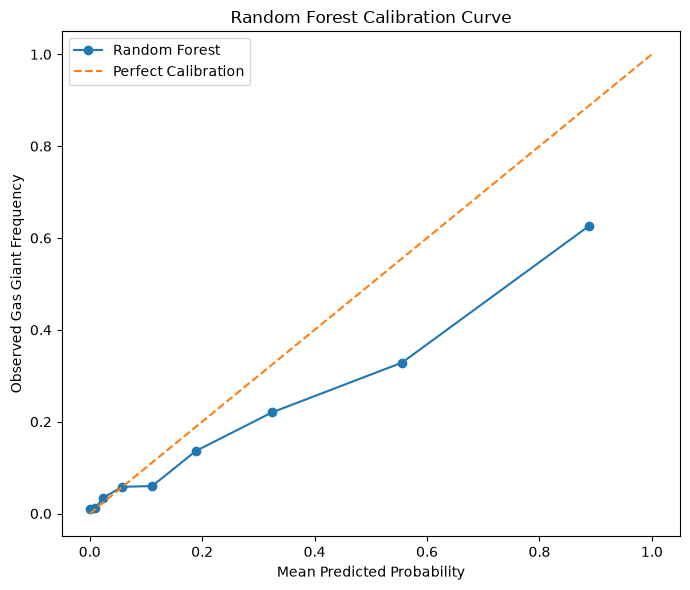

In [8]:
plt.figure(figsize=(7, 6))

plt.plot(
    rf_prob_pred,
    rf_prob_true,
    marker="o",
    label="Random Forest"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel(
    "Mean Predicted Probability"
)

plt.ylabel(
    "Observed Gas Giant Frequency"
)

plt.title(
    "Random Forest Calibration Curve"
)

plt.legend()

plt.tight_layout()

plt.show()

## Probability Reliability Table

The calibration curve provides a visual summary of probability reliability.

A reliability table provides the corresponding numerical information.

The predicted probabilities are divided into fixed probability intervals:

- 0.0–0.1
- 0.1–0.2
- ...
- 0.9–1.0

For each interval, the following quantities are calculated:

- Number of observations
- Mean predicted probability
- Observed gas-giant frequency
- Difference between observed frequency and predicted probability

The difference provides a direct measure of calibration error within each probability interval.

Bins with very few observations should be interpreted cautiously.

In [9]:
probability_bins = np.linspace(
    0,
    1,
    11
)

probability_labels = [
    "0.0–0.1",
    "0.1–0.2",
    "0.2–0.3",
    "0.3–0.4",
    "0.4–0.5",
    "0.5–0.6",
    "0.6–0.7",
    "0.7–0.8",
    "0.8–0.9",
    "0.9–1.0"
]

reliability_data = pd.DataFrame({
    "Probability": rf_probability,
    "Actual": y_test.values
})

reliability_data["Probability Bin"] = pd.cut(
    reliability_data["Probability"],
    bins=probability_bins,
    labels=probability_labels,
    include_lowest=True
)

reliability_table = (
    reliability_data
    .groupby(
        "Probability Bin",
        observed=False
    )
    .agg(
        Observations=("Actual", "size"),
        Mean_Predicted_Probability=(
            "Probability",
            "mean"
        ),
        Observed_Gas_Giant_Frequency=(
            "Actual",
            "mean"
        )
    )
    .reset_index()
)

reliability_table[
    "Calibration Error"
] = (
    reliability_table[
        "Observed_Gas_Giant_Frequency"
    ]
    -
    reliability_table[
        "Mean_Predicted_Probability"
    ]
)

reliability_table.round(3)

,Probability Bin,Observations,Mean_Predicted_Probability,Observed_Gas_Giant_Frequency,Calibration Error
0,0.0–0.1,3004,0.023,0.026,0.003
1,0.1–0.2,678,0.150,0.109,-0.041
2,0.2–0.3,402,0.249,0.187,-0.062
3,0.3–0.4,271,0.349,0.207,-0.142
4,0.4–0.5,193,0.454,0.259,-0.195
5,0.5–0.6,255,0.541,0.267,-0.275
6,0.6–0.7,132,0.652,0.515,-0.137
7,0.7–0.8,155,0.753,0.465,-0.288
8,0.8–0.9,152,0.852,0.493,-0.358
9,0.9–1.0,266,0.973,0.774,-0.198


## Brier Score

The Brier score measures the mean squared difference between predicted probabilities and the observed binary outcomes.

Lower values indicate better probabilistic accuracy.

The Brier score evaluates the quality of probability predictions rather than simply whether the final class prediction was correct.

This makes it particularly relevant to the central question of this notebook.

The Brier score is interpreted alongside other metrics because its value is influenced partly by the prevalence of the positive class.

In [10]:
rf_brier_score = brier_score_loss(
    y_test,
    rf_probability
)

print(
    "Random Forest Brier Score:",
    round(
        rf_brier_score,
        4
    )
)

Random Forest Brier Score: 0.103


## Calibration Comparison Across Models

The model with the best classification performance is not necessarily the model with the most reliable probabilities.

This section compares:

- Logistic Regression
- Random Forest
- Gradient Boosting

The comparison separates two different questions:

### Classification performance

How well does the model distinguish gas giants from non-gas giants?

### Probability reliability

Do the predicted probabilities correspond to observed class frequencies?

The primary probability-reliability metric is the Brier score.

ROC-AUC and Average Precision are included to describe discrimination, while F1 describes performance using the default 0.50 classification threshold.

In [11]:
models = {
    "Logistic Regression": logistic_regression,
    "Random Forest": random_forest,
    "Gradient Boosting": gradient_boosting
}

model_predictions = {}

for model_name, model in models.items():

    probability = model.predict_proba(
        X_test
    )[:, 1]

    prediction = (
        probability >= 0.5
    ).astype(int)

    model_predictions[model_name] = {
        "Probability": probability,
        "Prediction": prediction
    }

In [12]:
model_comparison = []

for model_name, results in model_predictions.items():

    probability = results["Probability"]
    prediction = results["Prediction"]

    model_comparison.append({
        "Model": model_name,

        "Accuracy": accuracy_score(
            y_test,
            prediction
        ),

        "Precision": precision_score(
            y_test,
            prediction,
            zero_division=0
        ),

        "Recall": recall_score(
            y_test,
            prediction,
            zero_division=0
        ),

        "F1": f1_score(
            y_test,
            prediction,
            zero_division=0
        ),

        "ROC-AUC": roc_auc_score(
            y_test,
            probability
        ),

        "Average Precision": average_precision_score(
            y_test,
            probability
        ),

        "Brier Score": brier_score_loss(
            y_test,
            probability
        )
    })

model_comparison = pd.DataFrame(
    model_comparison
)

model_comparison.round(4)

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision,Brier Score
0,Logistic Regression,0.8548,0.6410,0.0608,0.1111,0.7232,0.3540,0.1141
1,Random Forest,0.8535,0.5077,0.5985,0.5494,0.8654,0.5789,0.1030
2,Gradient Boosting,0.8624,0.6684,0.1545,0.2510,0.7745,0.4456,0.1053


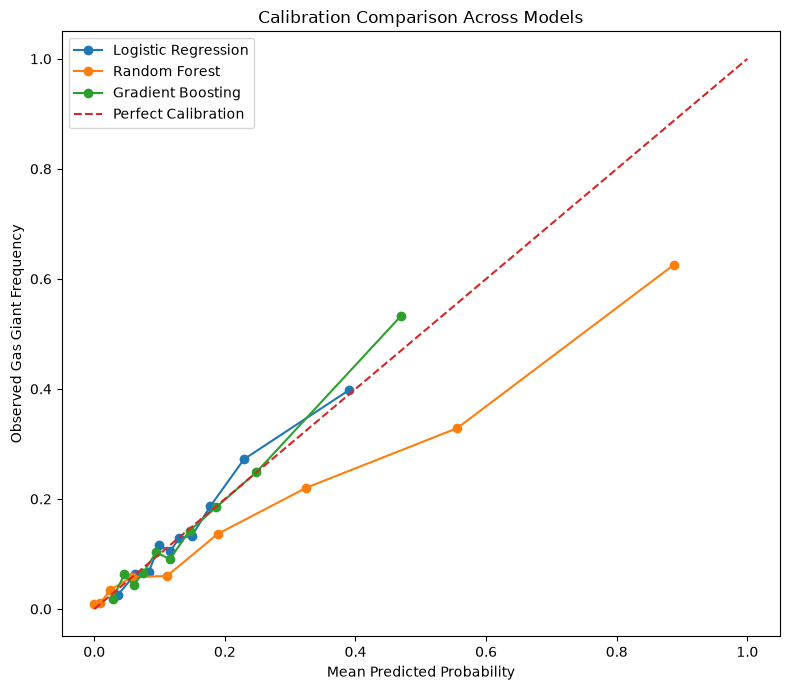

In [13]:
plt.figure(figsize=(8, 7))

for model_name, results in model_predictions.items():

    probability = results["Probability"]

    prob_true, prob_pred = calibration_curve(
        y_test,
        probability,
        n_bins=10,
        strategy="quantile"
    )

    plt.plot(
        prob_pred,
        prob_true,
        marker="o",
        label=model_name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel(
    "Mean Predicted Probability"
)

plt.ylabel(
    "Observed Gas Giant Frequency"
)

plt.title(
    "Calibration Comparison Across Models"
)

plt.legend()

plt.tight_layout()

plt.show()

## Calibration Methods

The Random Forest was selected as the final classifier in Notebook 03.

This section investigates whether its probability outputs can be improved through post-hoc calibration.

Two calibration approaches are evaluated:

### Sigmoid calibration

Also called Platt scaling.

This fits a sigmoid transformation to the model's outputs.

### Isotonic calibration

This fits a non-decreasing, non-parametric relationship between model scores and observed outcomes.

Calibration is performed using the training data through internal cross-validation.

The held-out testing data are used only for the final comparison of the resulting probability outputs.

The calibrated models are not used to replace the original Random Forest classifier selected in Notebook 03.

They are evaluated as probability-calibration variants.

In [14]:
rf_sigmoid_calibrated = CalibratedClassifierCV(
    estimator=random_forest,
    method="sigmoid",
    cv=5,
    n_jobs=-1
)

rf_sigmoid_calibrated.fit(
    X_train,
    y_train
)

rf_sigmoid_probability = (
    rf_sigmoid_calibrated
    .predict_proba(X_test)[:, 1]
)

print(
    "Sigmoid calibration complete."
)

Sigmoid calibration complete.


In [15]:
rf_isotonic_calibrated = CalibratedClassifierCV(
    estimator=random_forest,
    method="isotonic",
    cv=5,
    n_jobs=-1
)

rf_isotonic_calibrated.fit(
    X_train,
    y_train
)

rf_isotonic_probability = (
    rf_isotonic_calibrated
    .predict_proba(X_test)[:, 1]
)

print(
    "Isotonic calibration complete."
)

Isotonic calibration complete.


## Before and After Calibration

The original Random Forest probabilities are compared with probabilities produced after:

- Sigmoid calibration
- Isotonic calibration

The primary comparison concerns probability reliability.

The following are evaluated:

- Calibration curves
- Brier score

ROC-AUC and Average Precision are also reported to determine whether calibration changes the ranking quality of the predictions.

Because calibration is a monotonic or approximately monotonic transformation of model scores, discrimination may remain similar even when probability calibration changes.

In [16]:
calibration_comparison = pd.DataFrame({
    "Model": [
        "Uncalibrated Random Forest",
        "Sigmoid-Calibrated Random Forest",
        "Isotonic-Calibrated Random Forest"
    ],

    "Brier Score": [
        brier_score_loss(
            y_test,
            rf_probability
        ),

        brier_score_loss(
            y_test,
            rf_sigmoid_probability
        ),

        brier_score_loss(
            y_test,
            rf_isotonic_probability
        )
    ],

    "ROC-AUC": [
        roc_auc_score(
            y_test,
            rf_probability
        ),

        roc_auc_score(
            y_test,
            rf_sigmoid_probability
        ),

        roc_auc_score(
            y_test,
            rf_isotonic_probability
        )
    ],

    "Average Precision": [
        average_precision_score(
            y_test,
            rf_probability
        ),

        average_precision_score(
            y_test,
            rf_sigmoid_probability
        ),

        average_precision_score(
            y_test,
            rf_isotonic_probability
        )
    ]
})

calibration_comparison.round(4)

,Model,Brier Score,ROC-AUC,Average Precision
0,Uncalibrated Random Forest,0.1030,0.8654,0.5789
1,Sigmoid-Calibrated Random Forest,0.0905,0.8612,0.5742
2,Isotonic-Calibrated Random Forest,0.0897,0.8619,0.5779


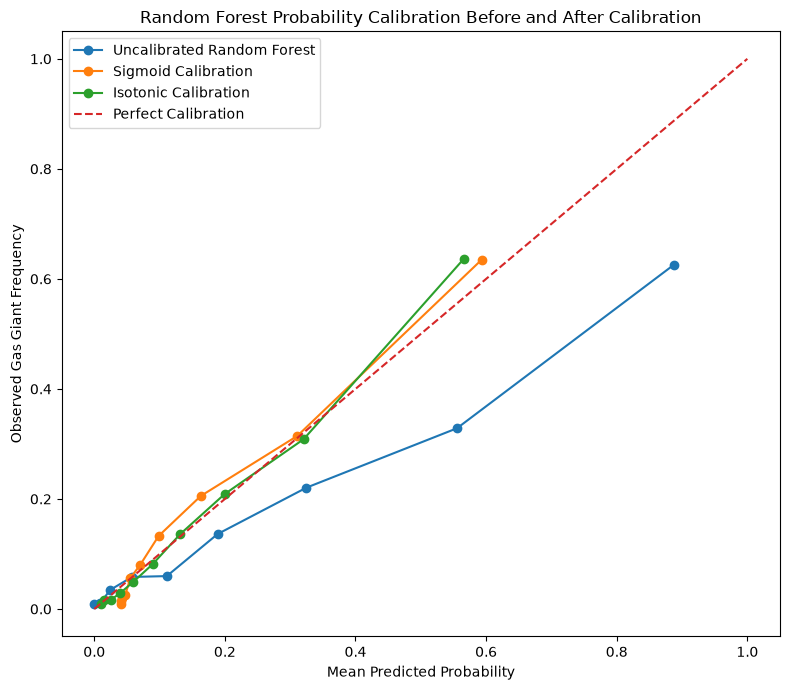

In [17]:
plt.figure(figsize=(8, 7))

calibrated_probabilities = {
    "Uncalibrated Random Forest": rf_probability,
    "Sigmoid Calibration": rf_sigmoid_probability,
    "Isotonic Calibration": rf_isotonic_probability
}

for model_name, probability in calibrated_probabilities.items():

    prob_true, prob_pred = calibration_curve(
        y_test,
        probability,
        n_bins=10,
        strategy="quantile"
    )

    plt.plot(
        prob_pred,
        prob_true,
        marker="o",
        label=model_name
    )

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Perfect Calibration"
)

plt.xlabel(
    "Mean Predicted Probability"
)

plt.ylabel(
    "Observed Gas Giant Frequency"
)

plt.title(
    "Random Forest Probability Calibration Before and After Calibration"
)

plt.legend()

plt.tight_layout()

plt.show()

## Reliability Tables After Calibration

Calibration curves provide a visual comparison.

Reliability tables provide a numerical comparison of the probability outputs before and after calibration.

The same fixed probability bins are used for each model so that the results can be compared directly.

In [18]:
def create_reliability_table(
    y_true,
    probabilities
):

    reliability_data = pd.DataFrame({
        "Probability": probabilities,
        "Actual": y_true.values
    })

    reliability_data["Probability Bin"] = pd.cut(
        reliability_data["Probability"],
        bins=probability_bins,
        labels=probability_labels,
        include_lowest=True
    )

    table = (
        reliability_data
        .groupby(
            "Probability Bin",
            observed=False
        )
        .agg(
            Observations=("Actual", "size"),
            Mean_Predicted_Probability=(
                "Probability",
                "mean"
            ),
            Observed_Gas_Giant_Frequency=(
                "Actual",
                "mean"
            )
        )
        .reset_index()
    )

    table["Calibration Error"] = (
        table[
            "Observed_Gas_Giant_Frequency"
        ]
        -
        table[
            "Mean_Predicted_Probability"
        ]
    )

    return table

In [19]:
uncalibrated_reliability = (
    create_reliability_table(
        y_test,
        rf_probability
    )
)

sigmoid_reliability = (
    create_reliability_table(
        y_test,
        rf_sigmoid_probability
    )
)

isotonic_reliability = (
    create_reliability_table(
        y_test,
        rf_isotonic_probability
    )
)

In [20]:
print(
    "Uncalibrated Random Forest"
)

display(
    uncalibrated_reliability.round(3)
)

print(
    "\nSigmoid-Calibrated Random Forest"
)

display(
    sigmoid_reliability.round(3)
)

print(
    "\nIsotonic-Calibrated Random Forest"
)

display(
    isotonic_reliability.round(3)
)

Uncalibrated Random Forest


,Probability Bin,Observations,Mean_Predicted_Probability,Observed_Gas_Giant_Frequency,Calibration Error
0,0.0–0.1,3004,0.023,0.026,0.003
1,0.1–0.2,678,0.150,0.109,-0.041
2,0.2–0.3,402,0.249,0.187,-0.062
3,0.3–0.4,271,0.349,0.207,-0.142
4,0.4–0.5,193,0.454,0.259,-0.195
5,0.5–0.6,255,0.541,0.267,-0.275
6,0.6–0.7,132,0.652,0.515,-0.137
7,0.7–0.8,155,0.753,0.465,-0.288
8,0.8–0.9,152,0.852,0.493,-0.358
9,0.9–1.0,266,0.973,0.774,-0.198



Sigmoid-Calibrated Random Forest


,Probability Bin,Observations,Mean_Predicted_Probability,Observed_Gas_Giant_Frequency,Calibration Error
0,0.0–0.1,3634,0.053,0.043,-0.010
1,0.1–0.2,695,0.141,0.186,0.045
2,0.2–0.3,370,0.252,0.227,-0.025
3,0.3–0.4,197,0.346,0.386,0.040
4,0.4–0.5,167,0.450,0.497,0.047
5,0.5–0.6,186,0.554,0.538,-0.016
6,0.6–0.7,170,0.644,0.694,0.050
7,0.7–0.8,89,0.731,0.865,0.135
8,0.8–0.9,0,NaN,NaN,NaN
9,0.9–1.0,0,NaN,NaN,NaN



Isotonic-Calibrated Random Forest


,Probability Bin,Observations,Mean_Predicted_Probability,Observed_Gas_Giant_Frequency,Calibration Error
0,0.0–0.1,3180,0.037,0.033,-0.005
1,0.1–0.2,971,0.142,0.137,-0.005
2,0.2–0.3,495,0.248,0.224,-0.024
3,0.3–0.4,258,0.348,0.391,0.043
4,0.4–0.5,291,0.451,0.498,0.048
5,0.5–0.6,128,0.547,0.570,0.023
6,0.6–0.7,96,0.644,0.802,0.159
7,0.7–0.8,47,0.738,0.894,0.156
8,0.8–0.9,42,0.857,0.857,0.001
9,0.9–1.0,0,NaN,NaN,NaN


## Calibration Error Summary

The absolute calibration error measures the distance between:

Mean predicted probability

and

Observed gas-giant frequency.

A lower average calibration error indicates closer agreement between predicted probabilities and observed frequencies.

This provides a descriptive summary alongside the Brier score and calibration curves.

In [21]:
calibration_error_summary = pd.DataFrame({
    "Model": [
        "Uncalibrated Random Forest",
        "Sigmoid Calibration",
        "Isotonic Calibration"
    ],

    "Mean Absolute Calibration Error": [
        np.mean(
            np.abs(
                uncalibrated_reliability[
                    "Calibration Error"
                ]
            )
        ),

        np.mean(
            np.abs(
                sigmoid_reliability[
                    "Calibration Error"
                ]
            )
        ),

        np.mean(
            np.abs(
                isotonic_reliability[
                    "Calibration Error"
                ]
            )
        )
    ]
})

calibration_error_summary.round(4)

,Model,Mean Absolute Calibration Error
0,Uncalibrated Random Forest,0.1699
1,Sigmoid Calibration,0.0461
2,Isotonic Calibration,0.0514


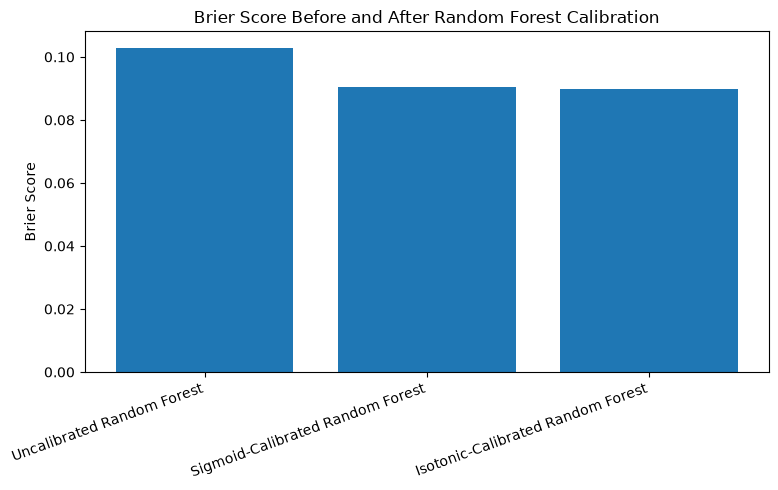

In [22]:
plt.figure(figsize=(8, 5))

plt.bar(
    calibration_comparison["Model"],
    calibration_comparison["Brier Score"]
)

plt.ylabel(
    "Brier Score"
)

plt.title(
    "Brier Score Before and After Random Forest Calibration"
)

plt.xticks(
    rotation=20,
    ha="right"
)

plt.tight_layout()

plt.show()

## Interpretation

This notebook evaluates the reliability of the probability outputs produced by the machine-learning models.

The Random Forest was evaluated first because it was selected as the final classifier in Notebook 03.

Its calibration curve and reliability table describe whether predicted probabilities correspond approximately to observed gas-giant frequencies across probability ranges.

The Brier score provides a numerical measure of probabilistic accuracy, with lower values indicating better probability predictions.

Calibration was also compared across Logistic Regression, Random Forest, and Gradient Boosting. This comparison separates classification performance from probability reliability. The model that performs best at classifying observations is not necessarily the model whose probabilities are most reliable.

Post-hoc sigmoid and isotonic calibration were then applied to the Random Forest using cross-validation on the training data. These methods were evaluated on the held-out testing data.

The calibrated models are not treated as replacements for the Random Forest selected in Notebook 03. Instead, they are investigated as probability-calibration variants.

If calibration improves the Brier score and brings the calibration curve closer to the perfect-calibration line, the calibrated probabilities provide stronger evidence of probabilistic reliability.

However, calibration performance should be interpreted cautiously when the testing dataset is small or when individual probability bins contain few observations.

The conclusions from this notebook therefore distinguish between:

1. Classification performance.
2. Ranking or discrimination ability.
3. Probability calibration.

These are related but different properties of a machine-learning model.

The final scientific interpretation should therefore avoid treating an uncalibrated model probability as a guaranteed probability that an individual planet is a gas giant.

In [23]:
best_brier_model = (
    model_comparison
    .sort_values(
        "Brier Score"
    )
    .iloc[0]
)

best_calibrated_model = (
    calibration_comparison
    .sort_values(
        "Brier Score"
    )
    .iloc[0]
)

print(
    "Probability Calibration and Reliability Summary"
)

print(
    "\nModel comparison:"
)

display(
    model_comparison.round(4)
)

print(
    "\nBest Brier score among original models:"
)

print(
    best_brier_model[
        "Model"
    ],
    "—",
    round(
        best_brier_model[
            "Brier Score"
        ],
        4
    )
)

print(
    "\nRandom Forest calibration comparison:"
)

display(
    calibration_comparison.round(4)
)

print(
    "\nBest Random Forest calibration configuration:"
)

print(
    best_calibrated_model[
        "Model"
    ],
    "—",
    round(
        best_calibrated_model[
            "Brier Score"
        ],
        4
    )
)

Probability Calibration and Reliability Summary

Model comparison:


,Model,Accuracy,Precision,Recall,F1,ROC-AUC,Average Precision,Brier Score
0,Logistic Regression,0.8548,0.6410,0.0608,0.1111,0.7232,0.3540,0.1141
1,Random Forest,0.8535,0.5077,0.5985,0.5494,0.8654,0.5789,0.1030
2,Gradient Boosting,0.8624,0.6684,0.1545,0.2510,0.7745,0.4456,0.1053



Best Brier score among original models:
Random Forest — 0.103

Random Forest calibration comparison:


,Model,Brier Score,ROC-AUC,Average Precision
0,Uncalibrated Random Forest,0.1030,0.8654,0.5789
1,Sigmoid-Calibrated Random Forest,0.0905,0.8612,0.5742
2,Isotonic-Calibrated Random Forest,0.0897,0.8619,0.5779



Best Random Forest calibration configuration:
Isotonic-Calibrated Random Forest — 0.0897
